This notebook compares Matching and Pauli Decompositions for a specific example.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")

from src.graphs import StaticGraph, IntersectingEdgesGraph, MultiEdgeGraph
from src.misc import graph_matchings_parallel
from qiskit.quantum_info import Operator

import numpy as np

# np.random.seed(123456789)
np.set_printoptions(floatmode='maxprec')
# This affects how NumPy creates new arrays
np.sctypeDict['complex_'] = np.complex128  # or np.complex256

# Commuting Example

Original graph:


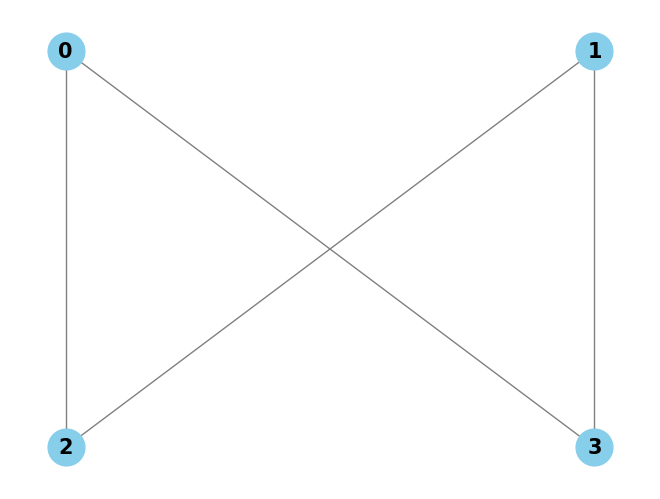

In [2]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11')}

delta_t = 0.1

G = StaticGraph(edges)
G.rot_angle = delta_t
print("Original graph:")
G.draw()

## Matching Decomposition

Relabeled graph:


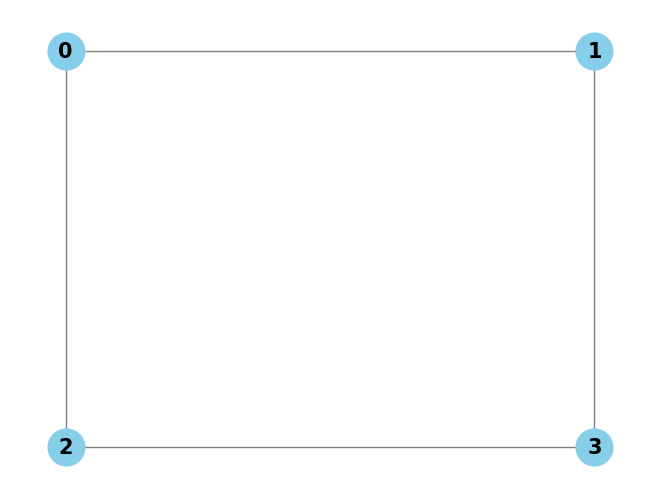

None

In [3]:
matchings = graph_matchings_parallel(edges)

relabeled_edges = set()
for m in matchings:
    relabeled_edges = relabeled_edges.union(m)

relabeled_G = StaticGraph(relabeled_edges)
print("Relabeled graph:")
display(relabeled_G.draw())

matching 1: {('00', '10'), ('11', '01')}


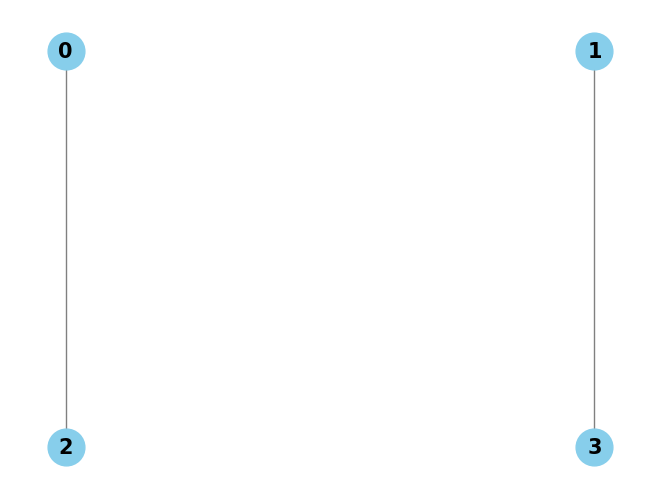

None

circuit 1:


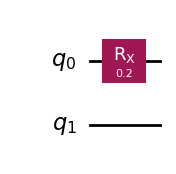

matching 2: {('11', '10'), ('00', '01')}


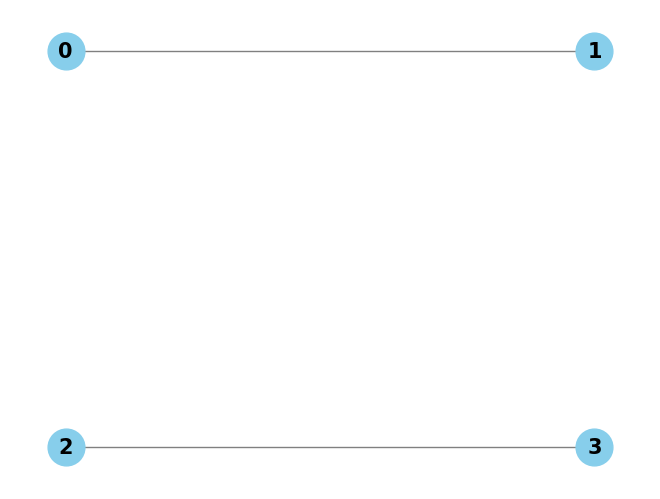

None

circuit 2:


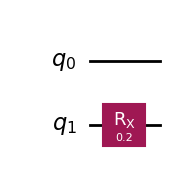

In [4]:
G = IntersectingEdgesGraph(edges, matchings='parallel')

for index, g in enumerate(G.subgraphs):
    print(f"matching {index+1}: {g.edges}")
    display(g.draw())
    qc = g.get_qc(simplified=True, angle=2 * delta_t)
    print(f'circuit {index+1}:')
    display(qc.draw('mpl'))
    

Full circuit:


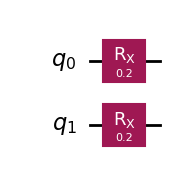

In [5]:
from qiskit import QuantumCircuit
import numpy as np

delta_t = 0.1

static_G = StaticGraph(edges)
intersecting_G = IntersectingEdgesGraph(edges, matchings='parallel')

n_steps = 1

full_qc = QuantumCircuit(static_G.n_qubits)
for _ in range(n_steps):
    for subgraph in intersecting_G.subgraphs:
        G = MultiEdgeGraph(subgraph.edges)
        sub_qc = G.get_qc(simplified=True, angle=2 * delta_t / n_steps)
        full_qc = full_qc.compose(sub_qc)

print("Full circuit:")
display(full_qc.draw('mpl'))

In [6]:
# Get the operator for the matching decomposition circuit
matching_operator = Operator(full_qc)
print(f"Matching circuit operator shape: {matching_operator.data.shape}")
# matching_operator = np.array(matching_operator.data)

Matching circuit operator shape: (4, 4)


## Pauli Decomposition

In [7]:
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np

In [8]:
# static_G = StaticGraph(edges)
H = relabeled_G.get_adj_mat()
n = relabeled_G.n_qubits

# Decompose the Hamiltonian into Pauli basis
pauli_strings = []
coeffs = []

for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n)]:
    P = Pauli(pauli_string)
    P_op = Operator(P).data
    coeff = np.trace(P_op.conj().T @ H) / (2**n)
    
    # For real symmetric matrices, coefficients should be real
    # Check that imaginary part is negligible
    if not np.isclose(np.imag(coeff), 0, atol=1e-10):
        print(f"Warning: Non-negligible imaginary coefficient {np.imag(coeff)} for Pauli string {pauli_string}")
    
    real_coeff = float(np.real(coeff))
    if not np.isclose(real_coeff, 0, atol=1e-10):
        pauli_strings.append(pauli_string)
        coeffs.append(real_coeff)

# Print the Pauli decomposition
print(f"Found {len(pauli_strings)} non-zero Pauli terms:")
for pauli_string, coeff in zip(pauli_strings, coeffs):
    print(f"{pauli_string}: {coeff:.2f}")


Found 2 non-zero Pauli terms:
IX: 1.00
XI: 1.00


Pauli Evolution Circuit:


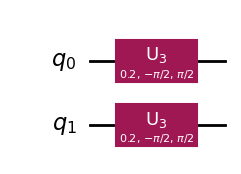

In [9]:
# Create quantum circuit 
pauli_qc = QuantumCircuit(n)

if coeffs:  # Only if we have non-zero coefficients
    pauli_op = SparsePauliOp(pauli_strings, coeffs)
    evo_gate = PauliEvolutionGate(pauli_op, time=delta_t)
    pauli_qc.append(evo_gate, range(n))

print("Pauli Evolution Circuit:")
decomposed_pauli_qc = pauli_qc.decompose().decompose().decompose()
display(decomposed_pauli_qc.draw('mpl'))

In [10]:
pauli_operator = Operator(decomposed_pauli_qc)
print(f"Pauli circuit operator shape: {pauli_operator.data.shape}")
# pauli_operator = np.array(pauli_operator.data)

Pauli circuit operator shape: (4, 4)


In [11]:
# Validate Pauli decomposition by reconstructing Hamiltonian
reconstructed_H = np.zeros_like(H, dtype=complex)

for pauli_string, coeff in zip(pauli_strings, coeffs):
    P = Pauli(pauli_string)
    P_matrix = Operator(P).data
    reconstructed_H += coeff * P_matrix

# Check if decomposition is correct
is_correct = np.allclose(H, reconstructed_H, atol=1e-10)
max_error = np.max(np.abs(H - reconstructed_H))

print("\nOriginal Adjacency Matrix:")
print(H)
print("\nReconstructed Adjacency Matrix:")
print(np.real(reconstructed_H))

print(f"\nPauli Decomposition correct: {is_correct}")
print(f"Max error: {max_error:.2e}")


Original Adjacency Matrix:
[[0 1 1 0]
 [1 0 0 1]
 [1 0 0 1]
 [0 1 1 0]]

Reconstructed Adjacency Matrix:
[[0. 1. 1. 0.]
 [1. 0. 0. 1.]
 [1. 0. 0. 1.]
 [0. 1. 1. 0.]]

Pauli Decomposition correct: True
Max error: 0.00e+00


In [12]:
# Calculate the difference between operators
operator_diff = matching_operator - pauli_operator

# Calculate different norms
frobenius_norm = np.linalg.norm(operator_diff, ord='fro')
spectral_norm = np.linalg.norm(operator_diff, ord=2)
# trace_norm = np.trace(np.sqrt(operator_diff @ operator_diff.conj().T))
max_norm = np.max(np.abs(operator_diff))

print("Matching Operator: ")
print(matching_operator.data)

print("Pauli Operator: ")
print(pauli_operator.data)

print("\nAre the operators close? ")
print(np.isclose(matching_operator.data, pauli_operator.data))

print(f"\nOperator difference norms:")
print(f"  Frobenius norm: {frobenius_norm:.6f}")
print(f"  Spectral norm (largest singular value): {spectral_norm:.6f}")
# print(f"  Trace norm: {trace_norm.real:.6f}")
print(f"  Max norm (element-wise): {max_norm:.6f}")


Matching Operator: 
[[ 0.99003329+0.j          0.        -0.09933467j  0.        -0.09933467j
  -0.00996671+0.j        ]
 [ 0.        -0.09933467j  0.99003329+0.j         -0.00996671+0.j
   0.        -0.09933467j]
 [ 0.        -0.09933467j -0.00996671+0.j          0.99003329+0.j
   0.        -0.09933467j]
 [-0.00996671+0.j          0.        -0.09933467j  0.        -0.09933467j
   0.99003329+0.j        ]]
Pauli Operator: 
[[ 9.90033289e-01+0.00000000e+00j -6.08249400e-18-9.93346654e-02j
  -6.08249400e-18-9.93346654e-02j -9.96671108e-03+1.22057008e-18j]
 [ 6.08249400e-18-9.93346654e-02j  9.90033289e-01+0.00000000e+00j
  -9.96671108e-03+0.00000000e+00j -6.08249400e-18-9.93346654e-02j]
 [ 6.08249400e-18-9.93346654e-02j -9.96671108e-03+0.00000000e+00j
   9.90033289e-01+0.00000000e+00j -6.08249400e-18-9.93346654e-02j]
 [-9.96671108e-03-1.22057008e-18j  6.08249400e-18-9.93346654e-02j
   6.08249400e-18-9.93346654e-02j  9.90033289e-01+0.00000000e+00j]]

Are the operators close? 
[[ True  True 

In [13]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

for n_steps in n_steps_list:
    # Matching decomposition with n_steps
    full_qc = QuantumCircuit(static_G.n_qubits)
    for i in range(n_steps):
        for subgraph in intersecting_G.subgraphs:
            G = MultiEdgeGraph(subgraph.edges)
            sub_qc = G.get_qc(simplified=True, angle= 2 * delta_t/ n_steps)
            full_qc = full_qc.compose(sub_qc)
    
    matching_operator = Operator(full_qc)
    
    # Pauli decomposition (exact, doesn't depend on n_steps)
    pauli_qc = QuantumCircuit(n)
    if coeffs:
        pauli_op = SparsePauliOp(pauli_strings, coeffs)
        evo_gate = PauliEvolutionGate(pauli_op, time=delta_t)
        pauli_qc.append(evo_gate, range(n))
    
    decomposed_pauli_qc = pauli_qc.decompose().decompose().decompose()
    pauli_operator = Operator(decomposed_pauli_qc)
    
    # Calculate difference
    operator_diff = matching_operator - pauli_operator
    two_norm = np.linalg.norm(operator_diff, ord=2)

    print(f"n_steps = {n_steps:3d}: ||Matching - Pauli||_2 = {two_norm:.6f}")


n_steps =   1: ||Matching - Pauli||_2 = 0.000000
n_steps =   2: ||Matching - Pauli||_2 = 0.000000
n_steps =   5: ||Matching - Pauli||_2 = 0.000000
n_steps =  10: ||Matching - Pauli||_2 = 0.000000
n_steps =  20: ||Matching - Pauli||_2 = 0.000000
n_steps =  50: ||Matching - Pauli||_2 = 0.000000
n_steps = 100: ||Matching - Pauli||_2 = 0.000000


# Non Commuting Example

Original graph:


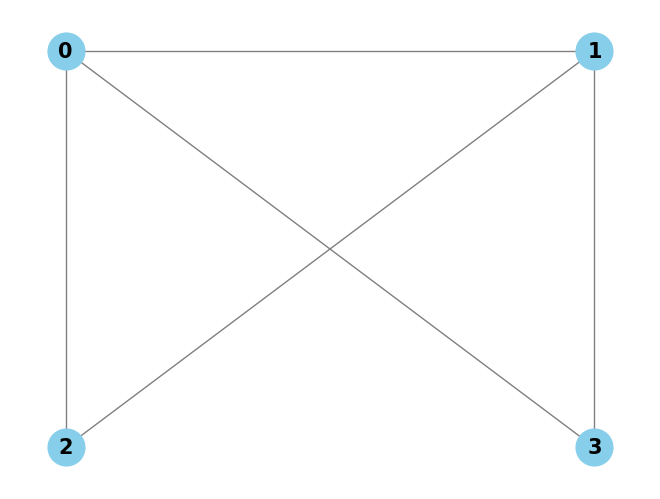

In [14]:
edges = {('00', '01'), ('00', '11'), ('01', '10'), ('00', '10'), ('01', '11')}

delta_t = 0.1

G = StaticGraph(edges)
G.rot_angle = delta_t
print("Original graph:")
G.draw()

Relabeled graph:


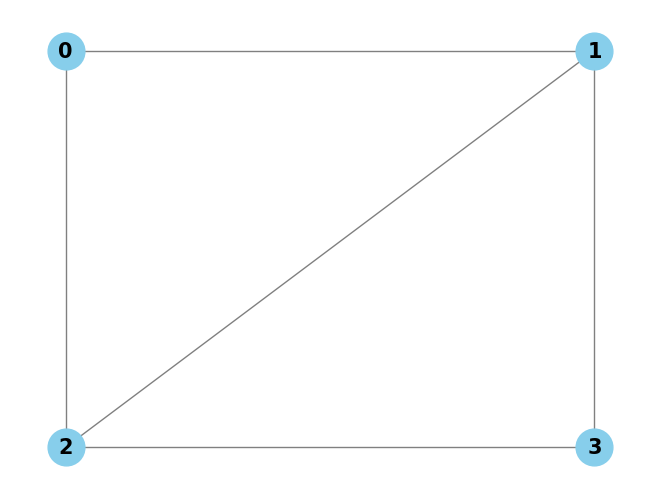

None

In [15]:
matchings = graph_matchings_parallel(edges)

relabeled_edges = set()
for m in matchings:
    relabeled_edges = relabeled_edges.union(m)

relabeled_G = StaticGraph(relabeled_edges)
print("Relabeled graph:")
display(relabeled_G.draw())

## Exact CTQW

In [16]:
# Exact time evolution: U(t) = exp(-iHt)
from scipy.linalg import expm # type: ignore

relabeled_G = StaticGraph(relabeled_edges)
H = relabeled_G.get_adj_mat()

exact_op = expm(-1j * H * delta_t)
exact_operator = Operator(exact_op)

## Matching Decomposition

matching 1: {('01', '10')}


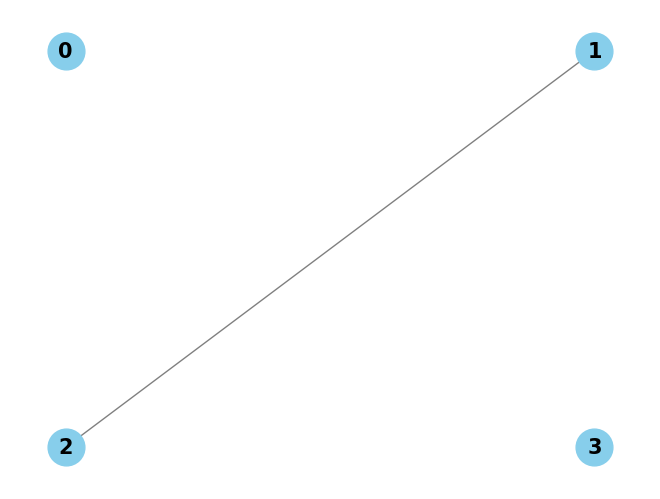

None

circuit 1:


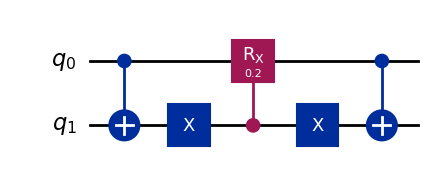

matching 2: {('10', '11'), ('01', '00')}


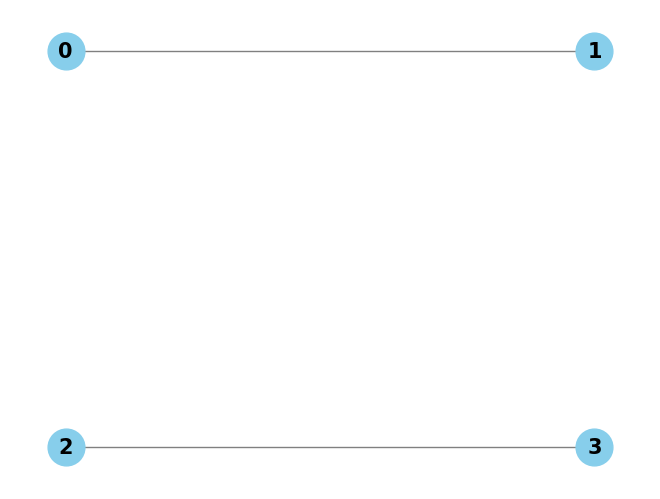

None

circuit 2:


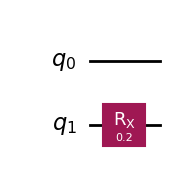

matching 3: {('10', '00'), ('01', '11')}


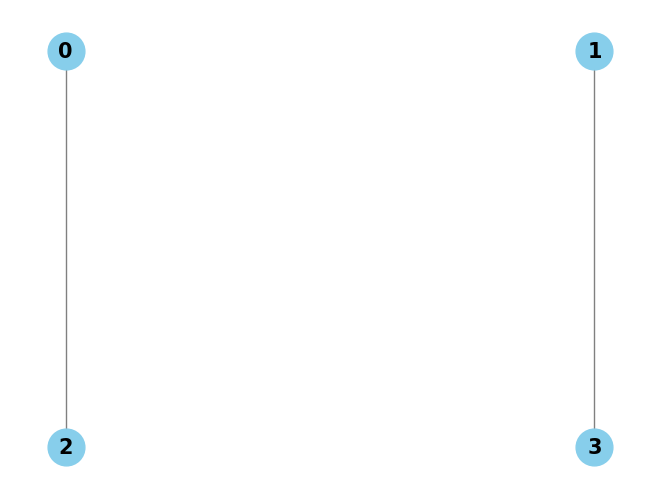

None

circuit 3:


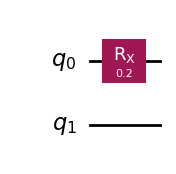

In [17]:
G = IntersectingEdgesGraph(edges, matchings='parallel')

for index, g in enumerate(G.subgraphs):
    print(f"matching {index+1}: {g.edges}")
    display(g.draw())
    g.rot_angle = 2 * delta_t
    qc = g.get_qc(simplified=True, angle=2 * delta_t)
    print(f'circuit {index+1}:')
    display(qc.draw('mpl'))
    

Full circuit:


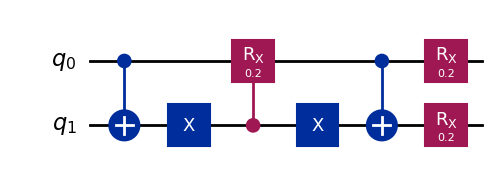

In [18]:
from qiskit import QuantumCircuit
import numpy as np

static_G = StaticGraph(edges)
intersecting_G = IntersectingEdgesGraph(edges, matchings='parallel')

n_steps = 1

full_qc = QuantumCircuit(static_G.n_qubits)
for _ in range(n_steps):
    for subgraph in intersecting_G.subgraphs:
        G = MultiEdgeGraph(subgraph.edges)
        sub_qc = G.get_qc(simplified=True, angle=2 * delta_t / n_steps)
        full_qc = full_qc.compose(sub_qc)

print("Full circuit:")
display(full_qc.draw('mpl'))

In [19]:
# Get the operator for the matching decomposition circuit
matching_operator = Operator(full_qc)
print(f"Matching circuit operator shape: {matching_operator.data.shape}")
print(matching_operator.data)

Matching circuit operator shape: (4, 4)
[[ 0.98508725+0.00099501j  0.        -0.09933467j  0.        -0.09933467j
  -0.00991692-0.09883841j]
 [-0.00991692-0.09883841j  0.99003329+0.j         -0.00996671+0.j
  -0.00991692-0.09883841j]
 [-0.00991692-0.09883841j -0.00996671+0.j          0.99003329+0.j
  -0.00991692-0.09883841j]
 [-0.00991692-0.09883841j  0.        -0.09933467j  0.        -0.09933467j
   0.98508725+0.00099501j]]


## Pauli Decomposition

In [20]:
# static_G = StaticGraph(edges)
H = relabeled_G.get_adj_mat()
n = relabeled_G.n_qubits

# Decompose the Hamiltonian into Pauli basis
pauli_strings = []
coeffs = []

for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n)]:
    P = Pauli(pauli_string)
    P_op = Operator(P).data
    coeff = np.trace(P_op.conj().T @ H) / (2**n)
    
    # For real symmetric matrices, coefficients should be real
    # Check that imaginary part is negligible
    if not np.isclose(np.imag(coeff), 0, atol=1e-10):
        print(f"Warning: Non-negligible imaginary coefficient {np.imag(coeff)} for Pauli string {pauli_string}")
    
    real_coeff = float(np.real(coeff))
    if not np.isclose(real_coeff, 0, atol=1e-10):
        pauli_strings.append(pauli_string)
        coeffs.append(real_coeff)

# Print the Pauli decomposition
print(f"Found {len(pauli_strings)} non-zero Pauli terms:")
for pauli_string, coeff in zip(pauli_strings, coeffs):
    print(f"{pauli_string}: {coeff:.2f}")


Found 4 non-zero Pauli terms:
IX: 1.00
XI: 1.00
XX: 0.50
YY: 0.50


Pauli Evolution Circuit:


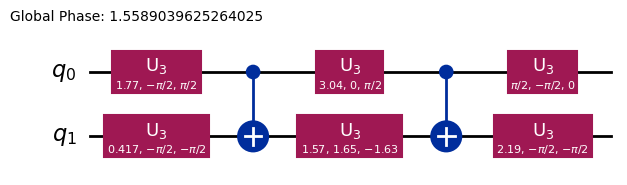

In [21]:
# Create quantum circuit 
from qiskit import transpile


pauli_qc = QuantumCircuit(n)

if coeffs:  # Only if we have non-zero coefficients
    pauli_op = SparsePauliOp(pauli_strings, coeffs)
    evo_gate = PauliEvolutionGate(pauli_op, time=delta_t)
    pauli_qc.append(evo_gate, range(n))

print("Pauli Evolution Circuit:")
# decomposed_pauli_qc = pauli_qc.decompose().decompose().decompose()
decomposed_pauli_qc = transpile(pauli_qc, basis_gates=['cx', 'u3'], optimization_level=3)
display(decomposed_pauli_qc.draw('mpl'))

In [22]:
pauli_operator = Operator(decomposed_pauli_qc)
print(f"Pauli circuit operator shape: {pauli_operator.data.shape}")
print(pauli_operator.data)

Pauli circuit operator shape: (4, 4)
[[ 9.90033289e-01+3.59087760e-16j -6.93889390e-17-9.93346654e-02j
  -8.61940727e-18-9.93346654e-02j -9.96671108e-03+5.37764278e-17j]
 [-9.91691904e-03-9.88384058e-02j  9.85087246e-01+9.95010820e-04j
  -9.91691904e-03-9.88384058e-02j -9.91691904e-03-9.88384058e-02j]
 [-9.91691904e-03-9.88384058e-02j -9.91691904e-03-9.88384058e-02j
   9.85087246e-01+9.95010820e-04j -9.91691904e-03-9.88384058e-02j]
 [-9.96671108e-03-9.28077060e-17j  1.82688066e-16-9.93346654e-02j
   1.26981758e-15-9.93346654e-02j  9.90033289e-01+3.50414142e-16j]]


In [23]:
# Validate Pauli decomposition by reconstructing Hamiltonian
reconstructed_H = np.zeros_like(H, dtype=complex)

for pauli_string, coeff in zip(pauli_strings, coeffs):
    P = Pauli(pauli_string)
    P_matrix = Operator(P).data
    reconstructed_H += coeff * P_matrix

# Check if decomposition is correct
is_correct = np.allclose(H, reconstructed_H, atol=1e-10)
max_error = np.max(np.abs(H - reconstructed_H))

print("\nOriginal Adjacency Matrix:")
print(H)
print("\nReconstructed Adjacency Matrix:")
print(np.real(reconstructed_H))

print(f"\nPauli Decomposition correct: {is_correct}")
print(f"Max error: {max_error:.2e}")


Original Adjacency Matrix:
[[0 1 1 0]
 [1 0 1 1]
 [1 1 0 1]
 [0 1 1 0]]

Reconstructed Adjacency Matrix:
[[0. 1. 1. 0.]
 [1. 0. 1. 1.]
 [1. 1. 0. 1.]
 [0. 1. 1. 0.]]

Pauli Decomposition correct: True
Max error: 0.00e+00


In [24]:
# Calculate the difference between operators
operator_diff = matching_operator - pauli_operator

# Calculate different norms
frobenius_norm = np.linalg.norm(operator_diff, ord='fro')
spectral_norm = np.linalg.norm(operator_diff, ord=2)
# trace_norm = np.trace(np.sqrt(operator_diff @ operator_diff.conj().T))
max_norm = np.max(np.abs(operator_diff))

print("Matching Operator: ")
print(matching_operator.data)

print("Pauli Operator: ")
print(pauli_operator.data)

print("\nAre the operators close? ")
print(np.isclose(matching_operator.data, pauli_operator.data))

print(f"\nOperator difference norms:")
print(f"  Frobenius norm: {frobenius_norm:.6f}")
print(f"  Spectral norm (largest singular value): {spectral_norm:.6f}")
# print(f"  Trace norm: {trace_norm.real:.6f}")
print(f"  Max norm (element-wise): {max_norm:.6f}")


Matching Operator: 
[[ 0.98508725+0.00099501j  0.        -0.09933467j  0.        -0.09933467j
  -0.00991692-0.09883841j]
 [-0.00991692-0.09883841j  0.99003329+0.j         -0.00996671+0.j
  -0.00991692-0.09883841j]
 [-0.00991692-0.09883841j -0.00996671+0.j          0.99003329+0.j
  -0.00991692-0.09883841j]
 [-0.00991692-0.09883841j  0.        -0.09933467j  0.        -0.09933467j
   0.98508725+0.00099501j]]
Pauli Operator: 
[[ 9.90033289e-01+3.59087760e-16j -6.93889390e-17-9.93346654e-02j
  -8.61940727e-18-9.93346654e-02j -9.96671108e-03+5.37764278e-17j]
 [-9.91691904e-03-9.88384058e-02j  9.85087246e-01+9.95010820e-04j
  -9.91691904e-03-9.88384058e-02j -9.91691904e-03-9.88384058e-02j]
 [-9.91691904e-03-9.88384058e-02j -9.91691904e-03-9.88384058e-02j
   9.85087246e-01+9.95010820e-04j -9.91691904e-03-9.88384058e-02j]
 [-9.96671108e-03-9.28077060e-17j  1.82688066e-16-9.93346654e-02j
   1.26981758e-15-9.93346654e-02j  9.90033289e-01+3.50414142e-16j]]

Are the operators close? 
[[False  True 

In [25]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

delta_t = 0.1

for n_steps in n_steps_list:
    # Matching decomposition with n_steps
    # full_qc = QuantumCircuit(static_G.n_qubits)
    # for i in range(n_steps):
    #     for subgraph in intersecting_G.subgraphs:
    #         G = MultiEdgeGraph(subgraph.edges)
    #         sub_qc = G.get_qc(simplified=True, angle=2 * delta_t / n_steps)
    #         full_qc = full_qc.compose(sub_qc)
    
    # matching_operator = Operator(full_qc)
    # Start with identity operator of appropriate dimension
    n_qubits = static_G.n_qubits
    identity_op = Operator(np.eye(2**n_qubits, dtype=complex))
    accumulated_operator = identity_op

    for i in range(n_steps):
        for subgraph in intersecting_G.subgraphs:
            G = MultiEdgeGraph(subgraph.edges)
            sub_qc = G.get_qc(simplified=True, angle=2 * delta_t / n_steps)
            # sub_qc = transpile(sub_qc, basis_gates=['cx', 'u3'], optimization_level=3)
            # Convert subcircuit to operator and accumulate
            sub_operator = Operator(sub_qc)
            
            # Matrix multiplication: new_op @ old_op (right-to-left composition)
            # print(np.linalg.norm(sub_operator @ accumulated_operator - accumulated_operator))
            accumulated_operator = sub_operator @ accumulated_operator
            # # accumulated_operator = accumulated_operator.compose(sub_operator)
            # # print(accumulated_operator)
            # accumulated_operator =  accumulated_operator @ sub_operator
 
    # Final result
    matching_operator = accumulated_operator

    
    H = relabeled_G.get_adj_mat()
    n = relabeled_G.n_qubits
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ H) / (2**n)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Initialize with identity operator
    identity_dim = 2**n
    pauli_operator = Operator(np.eye(identity_dim, dtype=complex))
    
    if coeffs:
        # Time per Trotter step
        dt = delta_t / n_steps
        
        # Accumulate operators in the loop (first-order Trotter decomposition)
        for step in range(n_steps):
            # Apply each Pauli term separately (first-order Trotter)
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                
                # Convert to circuit and then to operator
                temp_qc = QuantumCircuit(n)
                temp_qc.append(evo_gate, range(n))
                
                # Decompose to get actual gates and convert to operator
                decomposed_qc = transpile(temp_qc, basis_gates=['cx', 'u3'], optimization_level=3)
                step_operator = Operator(decomposed_qc)
                
                # Compose with accumulated operator
                pauli_operator = step_operator.compose(pauli_operator)
    
    # Calculate difference
    matching_vs_pauli = matching_operator - pauli_operator
    matching_vs_exact = matching_operator - exact_operator
    pauli_vs_exact = pauli_operator - exact_operator

    print(f"n_steps = {n_steps:3d}: ||Matching - exact||_2 = {np.linalg.norm(matching_vs_exact, ord=2):.6f}")
    print(f"n_steps = {n_steps:3d}: ||Pauli - exact||_2 = {np.linalg.norm(pauli_vs_exact, ord=2):.6f}")
    print(f"n_steps = {n_steps:3d}: ||Matching - Pauli||_2 = {np.linalg.norm(matching_vs_pauli, ord=2):.6f}")
    print()

n_steps =   1: ||Matching - exact||_2 = 0.099958
n_steps =   1: ||Pauli - exact||_2 = 0.009953
n_steps =   1: ||Matching - Pauli||_2 = 0.099958

n_steps =   2: ||Matching - exact||_2 = 0.099958
n_steps =   2: ||Pauli - exact||_2 = 0.004968
n_steps =   2: ||Matching - Pauli||_2 = 0.099958

n_steps =   5: ||Matching - exact||_2 = 0.099958
n_steps =   5: ||Pauli - exact||_2 = 0.001986
n_steps =   5: ||Matching - Pauli||_2 = 0.099958

n_steps =  10: ||Matching - exact||_2 = 0.099958
n_steps =  10: ||Pauli - exact||_2 = 0.000993
n_steps =  10: ||Matching - Pauli||_2 = 0.099958

n_steps =  20: ||Matching - exact||_2 = 0.099958
n_steps =  20: ||Pauli - exact||_2 = 0.000496
n_steps =  20: ||Matching - Pauli||_2 = 0.099958

n_steps =  50: ||Matching - exact||_2 = 0.099958
n_steps =  50: ||Pauli - exact||_2 = 0.000199
n_steps =  50: ||Matching - Pauli||_2 = 0.099958

n_steps = 100: ||Matching - exact||_2 = 0.099958
n_steps = 100: ||Pauli - exact||_2 = 0.000099
n_steps = 100: ||Matching - Pauli||

In [26]:
n_steps_list = [1, 2, 5, 10, 20, 50, 100]

delta_t = 0.1

for n_steps in n_steps_list:
    # Matching decomposition with n_steps
    n_qubits = static_G.n_qubits
    accumulated_matrix = np.eye(2**n_qubits, dtype=complex)

    for i in range(n_steps):
        for subgraph in intersecting_G.subgraphs:
            G = MultiEdgeGraph(subgraph.edges)
            sub_qc = G.get_qc(simplified=True, angle=2 * delta_t / n_steps)
            
            # Convert subcircuit to matrix using unitary simulator
            from qiskit_aer import UnitarySimulator
            backend = UnitarySimulator()
            job = backend.run(sub_qc)
            sub_matrix = job.result().get_unitary().data  # Extract numpy array from Operator
            
            # Matrix multiplication: new_matrix @ old_matrix (right-to-left composition)
            accumulated_matrix = sub_matrix @ accumulated_matrix
 
    # Final result
    matching_matrix = accumulated_matrix
    
    H = relabeled_G.get_adj_mat()
    n = relabeled_G.n_qubits
    
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []
    
    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n)]:
        P = Pauli(pauli_string)
        P_matrix = P.to_matrix()
        coeff = np.trace(P_matrix.conj().T @ H) / (2**n)
        
        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)
    
    # Initialize with identity matrix
    identity_dim = 2**n
    pauli_matrix = np.eye(identity_dim, dtype=complex)
    
    if coeffs:
        # Time per Trotter step
        dt = delta_t / n_steps
        
        # Initialize backend for matrix conversion
        from qiskit_aer import UnitarySimulator
        backend = UnitarySimulator()
        
        # Accumulate matrices in the loop (first-order Trotter decomposition)
        for step in range(n_steps):
            # Apply each Pauli term separately (first-order Trotter)
            for pauli_string, coeff in zip(pauli_strings, coeffs):
                single_pauli_op = SparsePauliOp([pauli_string], [coeff])
                evo_gate = PauliEvolutionGate(single_pauli_op, time=dt)
                
                # Convert to circuit and then to matrix
                temp_qc = QuantumCircuit(n)
                temp_qc.append(evo_gate, range(n))
                
                # Decompose to get actual gates and convert to matrix using unitary simulator
                decomposed_qc = transpile(temp_qc, basis_gates=['cx', 'u3'], optimization_level=3)
                job = backend.run(decomposed_qc)
                step_matrix = job.result().get_unitary().data  # Extract numpy array from Operator
                
                # Compose with accumulated matrix
                pauli_matrix = step_matrix @ pauli_matrix
    
    # Calculate difference
    matching_vs_pauli = matching_matrix - pauli_matrix
    matching_vs_exact = matching_matrix - exact_operator  # Assuming exact_operator is already a matrix
    pauli_vs_exact = pauli_matrix - exact_operator

    print(f"n_steps = {n_steps:3d}: ||Matching - exact||_2 = {np.linalg.norm(matching_vs_exact, ord=2):.6f}")
    print(f"n_steps = {n_steps:3d}: ||Pauli - exact||_2 = {np.linalg.norm(pauli_vs_exact, ord=2):.6f}")
    print(f"n_steps = {n_steps:3d}: ||Matching - Pauli||_2 = {np.linalg.norm(matching_vs_pauli, ord=2):.6f}")
    print()

n_steps =   1: ||Matching - exact||_2 = 0.099958
n_steps =   1: ||Pauli - exact||_2 = 0.009953
n_steps =   1: ||Matching - Pauli||_2 = 0.099958

n_steps =   2: ||Matching - exact||_2 = 0.099958
n_steps =   2: ||Pauli - exact||_2 = 0.004968
n_steps =   2: ||Matching - Pauli||_2 = 0.099958

n_steps =   5: ||Matching - exact||_2 = 0.099958
n_steps =   5: ||Pauli - exact||_2 = 0.001986
n_steps =   5: ||Matching - Pauli||_2 = 0.099958

n_steps =  10: ||Matching - exact||_2 = 0.099958
n_steps =  10: ||Pauli - exact||_2 = 0.000993
n_steps =  10: ||Matching - Pauli||_2 = 0.099958

n_steps =  20: ||Matching - exact||_2 = 0.099958
n_steps =  20: ||Pauli - exact||_2 = 0.000496
n_steps =  20: ||Matching - Pauli||_2 = 0.099958

n_steps =  50: ||Matching - exact||_2 = 0.099958
n_steps =  50: ||Pauli - exact||_2 = 0.000199
n_steps =  50: ||Matching - Pauli||_2 = 0.099958

n_steps = 100: ||Matching - exact||_2 = 0.099958
n_steps = 100: ||Pauli - exact||_2 = 0.000099
n_steps = 100: ||Matching - Pauli||